In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Connect and load
conn = sqlite3.connect("../db/nfl_skill_positions.db")
df = pd.read_sql_query("""
    SELECT s.*, p.display_name, p.college_name,
           p.draft_year, p.draft_round,
           p.height, p.weight
    FROM season_stats s
    JOIN players p ON s.player_id = p.player_id
""", conn)
conn.close()

#Position order we'll use throughout
pos_order = ["RB", "WR", "TE", "QB"]
pos_colors = {"RB": "#1D9E75", "WR": "#3B8BD4", "TE": "#E8593C", "QB": "#9B59B6"}

print(f"Loaded {len(df)} rows")
print(f"\nBreakdown by position:")
print(df["position"].value_counts())
print(f"\nAge range: {df['age'].min()} — {df['age'].max()}")

Loaded 5596 rows

Breakdown by position:
WR    2122
RB    1613
TE    1035
QB     826
Name: position, dtype: int64

Age range: 21 — 45


In [2]:
#Check the outlier ages
print("Players aged 35 and older:")
old_players = df[df["age"] >= 35][["display_name", "position", "season", "age"]].sort_values("age", ascending=False)
print(old_players.to_string())

Players aged 35 and older:
            display_name position  season  age
975            Tom Brady       QB    2022   45
974            Tom Brady       QB    2021   44
973            Tom Brady       QB    2020   43
972            Tom Brady       QB    2019   42
812     Vinny Testaverde       QB    2004   41
706           Jerry Rice       WR    2003   41
971            Tom Brady       QB    2018   41
1313          Drew Brees       QB    2020   41
255          Brett Favre       QB    2010   41
1312          Drew Brees       QB    2019   40
970            Tom Brady       QB    2017   40
705           Jerry Rice       WR    2002   40
254          Brett Favre       QB    2009   40
377      Matt Hasselbeck       QB    2015   40
2044       Aaron Rodgers       QB    2022   39
266          Doug Flutie       QB    2001   39
1945       Philip Rivers       QB    2020   39
253          Brett Favre       QB    2008   39
1311          Drew Brees       QB    2018   39
969            Tom Brady       QB

In [3]:
#Capping the age at 40 — keeps legitimate veteran careers
#Removes seasons where sample is too thin to be meaningful
df = df[df["age"] <= 40].copy()

print(f"Dataset after age cap: {len(df)} rows")
print(f"Age range: {df['age'].min()} — {df['age'].max()}")
print(f"\nBreakdown by position after cap:")
print(df["position"].value_counts())

Dataset after age cap: 5587 rows
Age range: 21 — 40

Breakdown by position after cap:
WR    2121
RB    1613
TE    1035
QB     818
Name: position, dtype: int64


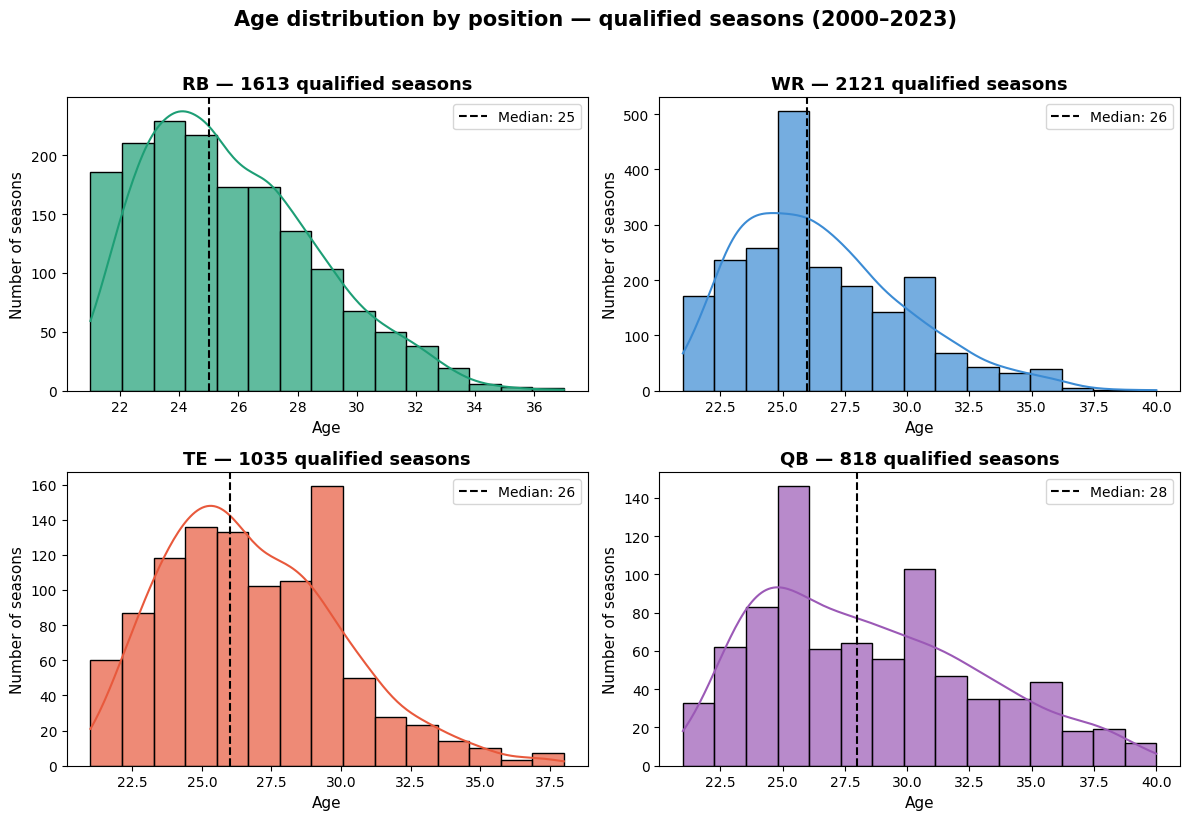


Median age by position:
  RB: median 25, mean 25.8
  WR: median 26, mean 26.6
  TE: median 26, mean 26.8
  QB: median 28, mean 28.5


In [4]:
#Age distribution by position
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for i, pos in enumerate(pos_order):
    pos_df = df[df["position"] == pos]
    ax = axes[i]
    
    sns.histplot(data=pos_df, x="age", bins=15, kde=True,
                 color=pos_colors[pos], alpha=0.7, ax=ax)
    
    median_age = pos_df["age"].median()
    ax.axvline(median_age, color="black", linestyle="--",
               linewidth=1.5, label=f"Median: {median_age:.0f}")
    
    ax.set_title(f"{pos} — {len(pos_df)} qualified seasons",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Age", fontsize=11)
    ax.set_ylabel("Number of seasons", fontsize=11)
    ax.legend(fontsize=10)

fig.suptitle("Age distribution by position — qualified seasons (2000–2023)",
             fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

print("\nMedian age by position:")
for pos in pos_order:
    median = df[df["position"] == pos]["age"].median()
    mean   = df[df["position"] == pos]["age"].mean()
    print(f"  {pos}: median {median:.0f}, mean {mean:.1f}")

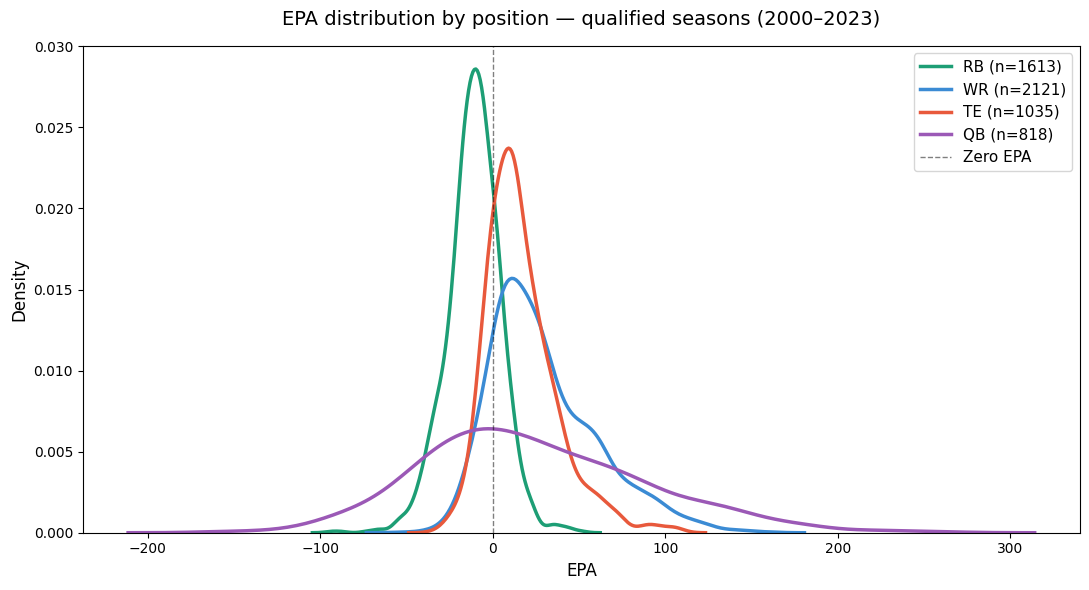


Mean EPA by position:
  RB: -10.8 mean EPA
  WR: 29.3 mean EPA
  TE: 16.4 mean EPA
  QB: 23.8 mean EPA


In [5]:
#EPA distribution by position
fig, ax = plt.subplots(figsize=(11, 6))

for pos in pos_order:
    pos_df = df[df["position"] == pos]
        
    if pos == "QB":
        epa_col = "passing_epa"
    elif pos == "RB":
        epa_col = "rushing_epa"
    else:
        epa_col = "receiving_epa"
    
    epa_data = pos_df[epa_col].dropna()
    
    sns.kdeplot(data=epa_data, label=f"{pos} (n={len(epa_data)})",
                color=pos_colors[pos], linewidth=2.5, ax=ax)

ax.axvline(0, color="black", linestyle="--",
           linewidth=1, alpha=0.5, label="Zero EPA")
ax.set_title("EPA distribution by position — qualified seasons (2000–2023)",
             fontsize=14, pad=15)
ax.set_xlabel("EPA", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\nMean EPA by position:")
for pos in pos_order:
    pos_df = df[df["position"] == pos]
    if pos == "QB":
        epa_col = "passing_epa"
    elif pos == "RB":
        epa_col = "rushing_epa"
    else:
        epa_col = "receiving_epa"
    mean_epa = pos_df[epa_col].mean()
    print(f"  {pos}: {mean_epa:.1f} mean EPA")

In [6]:
#Standardize EPA within position to make cross-position comparison valid
#Z-score = (value - position mean) / position standard deviation

def get_epa_col(position):
    if position == "QB":
        return "passing_epa"
    elif position == "RB":
        return "rushing_epa"
    else:
        return "receiving_epa"

#Calculate z-score within each position
df["epa_col"] = df["position"].apply(get_epa_col)
df["epa_raw"] = df.apply(lambda row: row[row["epa_col"]], axis=1)

#Standardize within position
df["epa_z"] = df.groupby("position")["epa_raw"].transform(
    lambda x: (x - x.mean()) / x.std()
)

print("Standardized EPA z-scores by position:")
for pos in pos_order:
    pos_df = df[df["position"] == pos]
    print(f"  {pos}: mean={pos_df['epa_z'].mean():.2f}, "
          f"std={pos_df['epa_z'].std():.2f}, "
          f"min={pos_df['epa_z'].min():.2f}, "
          f"max={pos_df['epa_z'].max():.2f}")

Standardized EPA z-scores by position:
  RB: mean=-0.00, std=1.00, min=-5.36, max=4.03
  WR: mean=-0.00, std=1.00, min=-2.65, max=4.23
  TE: mean=-0.00, std=1.00, min=-2.41, max=4.44
  QB: mean=-0.00, std=1.00, min=-2.84, max=3.68


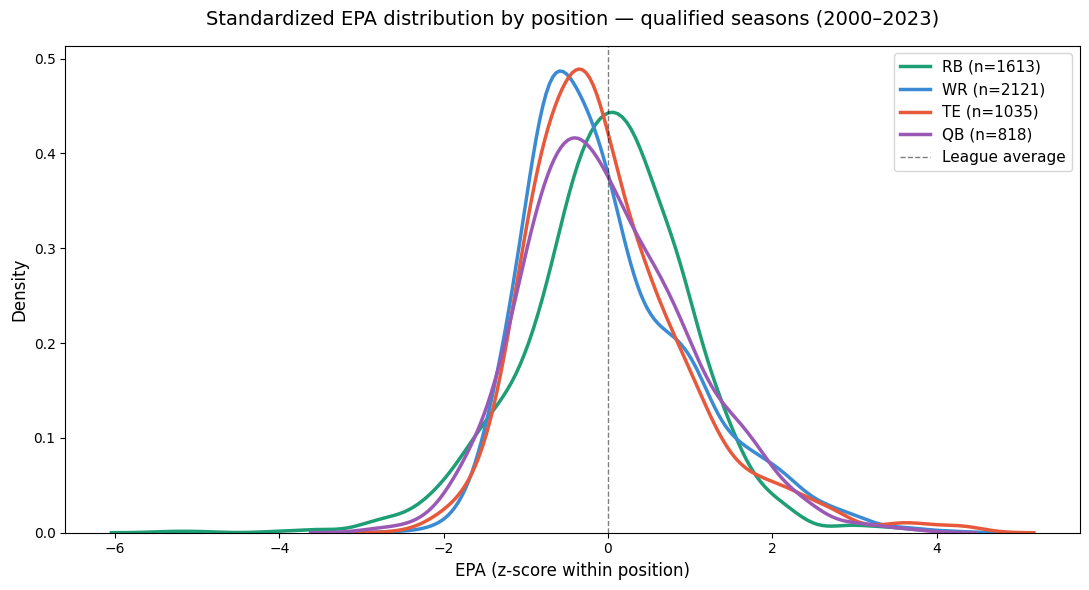

In [7]:
#Replot with standardized EPA — should now overlap cleanly
fig, ax = plt.subplots(figsize=(11, 6))

for pos in pos_order:
    pos_df = df[df["position"] == pos]
    sns.kdeplot(data=pos_df["epa_z"], label=f"{pos} (n={len(pos_df)})",
                color=pos_colors[pos], linewidth=2.5, ax=ax)

ax.axvline(0, color="black", linestyle="--",
           linewidth=1, alpha=0.5, label="League average")
ax.set_title("Standardized EPA distribution by position — qualified seasons (2000–2023)",
             fontsize=14, pad=15)
ax.set_xlabel("EPA (z-score within position)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()